# 045 — Deterministic Phase 4.5 Multimodal / Multi-Format Test Corpus Evaluation

## 1. Objective

This notebook evaluates the deterministic Phase 4 / Phase 4.5 ingestion and retrieval path against a mixed-format test corpus under [data/files/test](../data/files/test) without using Phase 5 agentic workflows.

It is intentionally notebook-first, local-only, and inspectable. The workflow reuses the existing registry-driven loaders, manifest-driven incremental indexing, Phase 4 reranking, and the established export/reporting bundle.

## 2. Test Scope

The notebook will:

- recursively scan [data/files/test](../data/files/test) for supported and unsupported file types;
- print file counts by extension and modality;
- ingest supported files through the existing local loaders;
- index the corpus with the existing manifest-driven incremental pipeline;
- run deterministic Phase 4 retrieval and answer generation over manual QA questions from [data/manual_qa](../data/manual_qa);
- export CSV, XLSX, JSON, and HTML artifacts under the existing outputs convention;
- preserve citations, source previews, and compatibility with the existing reporting workflow.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

WORKING_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIRECTORY.parent if WORKING_DIRECTORY.name == "notebooks" else WORKING_DIRECTORY
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from cial_knowledge_os.config import KnowledgeOSConfig, Phase4Config
from cial_knowledge_os.file_formats import FORMAT_REGISTRY, scan_file_format_readiness
from cial_knowledge_os.infra.qdrant_health import check_qdrant_health
from cial_knowledge_os.loaders import discover_knowledge_documents, load_pdf_paths, summarize_documents
from cial_knowledge_os.ocr.tesseract_ocr import TesseractOCREngine
from cial_knowledge_os.phase4_pipeline import Phase4RAGPipeline
from cial_knowledge_os.phase4_runner import Phase4Runner
from cial_knowledge_os.vectorstore import create_qdrant_client

pd.set_option("display.max_colwidth", 140)

TEST_CORPUS_ROOT = PROJECT_ROOT / "data" / "files" / "test"
QUESTION_ROOT = PROJECT_ROOT / "data" / "manual_qa"
DEFAULT_QUESTION_FILE = QUESTION_ROOT / "CIAL_Multimodal_Test_Questions.txt"

FORCE_REBUILD_INDEX = True
LOCAL_FILES_ONLY = True
RUN_ALL_QUESTIONS = True
MAX_QUESTIONS = None  # None means unlimited; set RUN_ALL_QUESTIONS=False and a positive integer for smoke tests.
RUN_SMOKE_TEST = False
OCR_ENABLED = True
TESSERACT_CMD = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

extension_frame = pd.DataFrame()
modality_frame = pd.DataFrame()

SUPPORTED_EXTENSIONS = {
    ".pdf",
    ".docx",
    ".doc",
    ".xlsx",
    ".xls",
    ".csv",
    ".pptx",
    ".ppt",
    ".txt",
    ".md",
    ".markdown",
    ".html",
    ".htm",
    ".json",
    ".xml",
    ".yaml",
    ".yml",
    ".png",
    ".jpg",
    ".jpeg",
    ".tiff",
    ".tif",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Test corpus root: {TEST_CORPUS_ROOT}")
print(f"Question root: {QUESTION_ROOT}")
print(f"Run all questions: {RUN_ALL_QUESTIONS}")
print(f"Max questions: {MAX_QUESTIONS}")

print(f"Run smoke test: {RUN_SMOKE_TEST}")
print(f"OCR enabled: {OCR_ENABLED}")

Project root: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS
Test corpus root: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\files\test
Question root: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\manual_qa
Run all questions: True
Max questions: None
Run smoke test: False
OCR enabled: True


## 3. Configuration

The notebook uses the existing configurable Phase 4 layer with a test-corpus override. The corpus and question paths are deliberately pointed at [data/files/test](../data/files/test) and [data/manual_qa](../data/manual_qa) so the workflow can be reused for multimodal corpus validation.

In [2]:
# OCR preflight and readiness checks.

ocr_engine = TesseractOCREngine(language="eng")
override_cmd = TESSERACT_CMD if TESSERACT_CMD and Path(TESSERACT_CMD).expanduser().exists() else None
preflight = ocr_engine.preflight(explicit_cmd=override_cmd, enabled=OCR_ENABLED)

print(f"pytesseract installed: {preflight['pytesseract_installed']}")
print(f"Pillow installed: {preflight['pillow_installed']}")
print(f"tesseract executable: {preflight['tesseract_executable']}")
print(f"tesseract version: {preflight['tesseract_version']}")
print(f"OCR status: {preflight['status']}")

if not OCR_ENABLED:
    warnings.warn("OCR disabled; image OCR will be skipped for this notebook run.", stacklevel=2)
elif preflight['status'] != 'ready':
    raise RuntimeError("OCR is enabled but local OCR is not ready. Install pytesseract and Pillow with 'pip install pytesseract pillow' and install Tesseract OCR locally, or set TESSERACT_CMD to the executable path.")
else:
    print("OCR is ready for local image OCR.")

pytesseract installed: True
Pillow installed: True
tesseract executable: C:\Program Files\Tesseract-OCR\tesseract.exe
tesseract version: 5.5.0.20241111
OCR status: ready
OCR is ready for local image OCR.


## 4.5 OCR Install Guidance and Preflight

OCR is run locally and offline for PNG, JPG/JPEG, and TIFF files. To enable it, install the Python packages and a local Tesseract binary.

Python package:
pip install pytesseract pillow

Windows Tesseract binary:
Install Tesseract OCR locally and either add it to PATH or set:
TESSERACT_CMD = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


## 4. Test Corpus Discovery

The corpus discovery step uses the shared file-format registry and scans the test folder recursively so unsupported files are surfaced in a structured way instead of being silently ignored.

In [3]:
# Print the support matrix for the expected multi-format corpus.

support_rows = []
for definition in FORMAT_REGISTRY:
    ext_values = ", ".join(f".{ext}" for ext in definition.extensions)
    loader_name = "ocr" if definition.requires_ocr else "registry_loader"
    support_rows.append(
        {
            "Format": definition.format_label,
            "Extension": ext_values,
            "Loader": loader_name,
            "OCR Required": bool(definition.requires_ocr),
            "Status": definition.support_status.value,
        }
    )

# Append a clear unsupported row for any additional file types.
support_rows.append(
    {
        "Format": "Unsupported others",
        "Extension": ".bin, .exe, .zip, .rar, .7z, .mp3, .mp4, .dwg, .sldprt",
        "Loader": "none",
        "OCR Required": False,
        "Status": "skipped_with_warning",
    }
)
support_frame = pd.DataFrame(support_rows)
display(support_frame[["Format", "Extension", "Loader", "OCR Required", "Status"]])

# Recursively scan the configured corpus and summarize by extension.
if not TEST_CORPUS_ROOT.exists():
    display(Markdown(f"### Corpus not found\nExpected test corpus at {TEST_CORPUS_ROOT}. Create the folder and place files there before running the notebook."))
else:
    readiness = scan_file_format_readiness(TEST_CORPUS_ROOT)
    extension_rows = []
    for item in readiness.get("extensions") or []:
        extension_rows.append(
            {
                "extension": item.get("extension", ""),
                "count": item.get("count", 0),
                "category": item.get("category", ""),
                "format_label": item.get("format_label", ""),
                "support_status": item.get("support_status", ""),
                "ingestion_enabled": item.get("ingestion_enabled", False),
                "requires_ocr": item.get("requires_ocr", False),
            }
        )
    extension_frame = pd.DataFrame(extension_rows).sort_values(["count", "extension"], ascending=[False, True])
    display(extension_frame)
    print("\nSummary")
    print(json.dumps({
        "total_files": readiness.get("total_files", 0),
        "processable_files": readiness.get("processable_files", 0),
        "ocr_files": readiness.get("ocr_files", 0),
        "recognized_future_files": readiness.get("recognized_future_files", 0),
        "unsupported_files": readiness.get("unsupported_files", 0),
    }, indent=2))

,Format,Extension,Loader,OCR Required,Status
0,PDF,.pdf,registry_loader,False,SUPPORTED_NOW
1,Word,".docx, .doc",registry_loader,False,SUPPORTED_NOW
2,Excel,".xlsx, .xls",registry_loader,False,SUPPORTED_NOW
3,CSV,.csv,registry_loader,False,SUPPORTED_NOW
4,PowerPoint,".pptx, .ppt",registry_loader,False,SUPPORTED_NOW
5,Text,.txt,registry_loader,False,SUPPORTED_NOW
6,Markdown,".md, .markdown",registry_loader,False,SUPPORTED_NOW
7,HTML,".html, .htm",registry_loader,False,SUPPORTED_NOW
8,JSON,.json,registry_loader,False,SUPPORTED_NOW
9,XML,.xml,registry_loader,False,SUPPORTED_NOW


,extension,count,category,format_label,support_status,ingestion_enabled,requires_ocr
0,download,15,Unsupported,Unsupported,UNSUPPORTED,False,False
1,pdf,9,Core Enterprise Documents,PDF,SUPPORTED_NOW,True,False
2,css,6,Unsupported,Unsupported,UNSUPPORTED,False,False
3,png,6,Images with OCR,PNG,OCR_SUPPORTED,True,True
4,json,3,Technical Documentation,JSON,SUPPORTED_NOW,True,False
5,txt,3,Core Enterprise Documents,Text,SUPPORTED_NOW,True,False
6,xml,3,Technical Documentation,XML,SUPPORTED_NOW,True,False
7,docx,2,Core Enterprise Documents,Word,SUPPORTED_NOW,True,False
8,html,2,Technical Documentation,HTML,SUPPORTED_NOW,True,False
9,csv,1,Core Enterprise Documents,CSV,SUPPORTED_NOW,True,False



Summary
{
  "total_files": 57,
  "processable_files": 34,
  "ocr_files": 7,
  "recognized_future_files": 1,
  "unsupported_files": 22
}


## 5. Multi-Format Ingestion

This section loads supported files from the test corpus using the existing loader stack. If a specific loader is unavailable, it logs a warning and continues rather than crashing the notebook.

In [4]:
# Discover processable files and ingest them with the existing loader registry.

config_like = KnowledgeOSConfig(project_root=PROJECT_ROOT, knowledge_root=TEST_CORPUS_ROOT)
corpus_root, discovered_paths = discover_knowledge_documents(config_like)

if not discovered_paths:
    display(Markdown("### No ingestible files discovered. Add supported files under the test corpus and rerun this cell."))
    documents = []
else:
    documents = load_pdf_paths(discovered_paths, corpus_root=corpus_root, config=None)
    summary = summarize_documents(documents)
    print(json.dumps(summary, indent=2))

    # Build modality counts from the registry and OCR metadata when available.
    modality_counts: dict[str, int] = {}
    for document in documents:
        metadata = document.metadata or {}
        suffix = Path(str(metadata.get("source", ""))).suffix.casefold()
        if metadata.get("requires_ocr") or suffix in {".png", ".jpg", ".jpeg", ".tiff", ".tif"}:
            modality = "image_ocr"
        elif suffix in {".xlsx", ".xls", ".csv"}:
            modality = "spreadsheet"
        elif suffix in {".pptx", ".ppt"}:
            modality = "presentation"
        elif suffix in {".pdf", ".docx", ".doc"}:
            modality = "document"
        else:
            modality = "text"
        modality_counts[modality] = modality_counts.get(modality, 0) + 1

    print("\nModality counts")
    print(json.dumps(modality_counts, indent=2))

    modality_frame = pd.DataFrame(
        [{"modality": key, "count": value} for key, value in sorted(modality_counts.items())]
    )
    display(modality_frame)

document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
[INFO] 2026-07-08 11:37:04,741 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 11:37:04,766 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-08 11:37:05,228 [RapidOCR] base.py:23: Using engine_na

{
  "document_count": 412,
  "total_characters": 1817527,
  "average_characters": 4411.5,
  "loader_counts": {
    "csv": 1,
    "docling": 4,
    "html": 2,
    "json": 3,
    "markdown": 1,
    "pymupdf": 394,
    "text": 3,
    "xml": 3,
    "yaml": 1
  },
  "support_status_counts": {
    "SUPPORTED_NOW": 412
  },
  "ocr_status_counts": {},
  "sources": [
    "CIAL Knowledge OS_ Building an AI-Native Knowledge Infrastructure for Airport Operations.docx",
    "CISG-2023-01-Information Security Practices for Government Entities.pdf",
    "CISG-2024-01-Secure Application Design, Development & Operations.pdf",
    "CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf",
    "CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf",
    "CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf",
    "CISG-2025-03-Cyber Defense Controls for MSMEs.pdf",
    "CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf",
    "CISG-2026-02- AI-Assisted Vulnerabi

e:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\.venv\Lib\site-packages\docling_core\types\doc\document.py:3020: UserWarning: Provenance bbox coordinate r on page 1 is outside page bounds: value=7.0 > hi=6.0; clamping to 6.0
  prov.bbox = cls._clamp_bbox_to_page(
e:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\.venv\Lib\site-packages\docling_core\types\doc\document.py:3020: UserWarning: Provenance bbox coordinate r on page 2 is outside page bounds: value=9.0 > hi=8.0; clamping to 8.0
  prov.bbox = cls._clamp_bbox_to_page(


,modality,count
0,document,396
1,presentation,1
2,spreadsheet,2
3,text,13


## 6. Manifest and Incremental Indexing

This section configures the shared Phase 4 pipeline with the test corpus root and the incremental manifest path. The notebook uses the existing indexing flow rather than duplicating chunking or upsert logic.

In [5]:
# Configure the Phase 4 pipeline to point at the test corpus and use the existing manifest-based indexing.

config = Phase4Config(
    project_root=PROJECT_ROOT,
    knowledge_root=TEST_CORPUS_ROOT,
    document_manifest_path=PROJECT_ROOT / "data" / "indexes" / "document_manifest.json",
    qdrant_mode="server",
    qdrant_url="http://localhost:6333",
    qdrant_collection_name="cial_phase4_multimodal_test",
    qdrant_batch_size=32,
    qdrant_upsert_wait=True,
    retrieval_mode="hybrid",
    dense_top_k=8,
    bm25_top_k=8,
    retrieval_top_k=8,
    rrf_k=40,
    max_context_tokens=4096,
    reranker_candidate_top_k=20,
    reranker_batch_size=8,
    reranker_local_files_only=LOCAL_FILES_ONLY,
    min_selected_evidence=2,
    max_selected_evidence=4,
    reranker_score_threshold=-4.0,
    fallback_to_top_n_if_empty=True,
    fallback_top_n=2,
    weak_evidence_answer_allowed=True,
    answer_detail_level="detailed",
    min_answer_words=150,
    max_answer_words=None,
    prefer_structured_answers=True,
    adaptive_answer_sections=True,
    include_decision_notes=True,
    generation_retries=1,
    retry_cooldown_seconds=5,
    evidence_token_budget=1600,
    selected_evidence_target_min_tokens=600,
    selected_evidence_target_max_tokens=1000,
    evidence_max_chunks_per_source=2,
    evidence_redundancy_threshold=0.85,
    phase4_trace_mode="full",
    incremental_indexing_enabled=True,
    force_rebuild_index=FORCE_REBUILD_INDEX,
    max_inline_manual_questions=None if RUN_ALL_QUESTIONS or MAX_QUESTIONS is None else int(MAX_QUESTIONS),
    allow_large_run=RUN_ALL_QUESTIONS or MAX_QUESTIONS is None,
    ocr_enabled=OCR_ENABLED,
    ocr_engine="tesseract",
    ocr_language="eng",
    observability_enabled=True,
    observability_console=False,
    observability_trace_jsonl=True,
    observability_progress_log=True,
    observability_telemetry=False,
)

try:
    qdrant_client = create_qdrant_client(config)
    qdrant_health = check_qdrant_health(qdrant_client, config.qdrant_collection_name)
    print(json.dumps(qdrant_health, indent=2))
except Exception as exc:  # pragma: no cover - notebook resilience
    warnings.warn(f"qdrant_unavailable: {exc}", stacklevel=2)
    config.qdrant_mode = "embedded"
    print("Falling back to embedded Qdrant mode because the configured server was not reachable.")

try:
    pipeline = Phase4RAGPipeline(config)
    print("Phase 4 pipeline created successfully.")
except Exception as exc:  # pragma: no cover - notebook resilience
    pipeline = None
    warnings.warn(f"pipeline_init_failed: {exc}", stacklevel=2)
    display(Markdown("### Pipeline initialization warning\nThe deterministic Phase 4 pipeline could not be created. Review the warning above and ensure local model dependencies are available."))

{
  "reachable": true,
  "collection_name": "cial_phase4_multimodal_test",
  "collection_exists": true,
  "collection_status": "green",
  "point_count": 3299,
  "indexed_vector_count": 0,
  "optimizer_status": "green",
  "vector_dimension": 1024,
  "dimension_matches": null,
  "warnings": [],
  "errors": [],
  "passed": true
}
Phase 4 pipeline created successfully.


## 7. Chunk / Evidence Statistics

The notebook reports chunk and evidence statistics from the indexed corpus so ingestion issues can be diagnosed quickly.

In [6]:
if pipeline is not None:
    try:
        documents = pipeline.load()
        chunks = pipeline.chunk()
        vectors = pipeline.embed()
        pipeline.index()
        print({"documents": len(documents), "chunks": len(chunks), "vectors": len(vectors)})
        print("manifest_path:", config.document_manifest_path)
        print("manifest_exists:", config.document_manifest_path.exists())
        if config.document_manifest_path.exists():
            manifest = json.loads(config.document_manifest_path.read_text(encoding="utf-8"))
            print("manifest_entries:", len(manifest.get("entries", [])))
    except Exception as exc:  # pragma: no cover - notebook resilience
        warnings.warn(f"indexing_failed: {exc}", stacklevel=2)
        documents = []
        chunks = []
        vectors = []
else:
    documents = []
    chunks = []
    vectors = []

if chunks:
    chunk_frame = pd.DataFrame(
        [
            {
                "source": chunk.metadata.get("source_filename", ""),
                "file_type": chunk.metadata.get("file_format_label", ""),
                "loader": chunk.metadata.get("loader_type", ""),
                "requires_ocr": bool(chunk.metadata.get("requires_ocr", False)),
                "text_length": len(chunk.page_content or ""),
            }
            for chunk in chunks
        ]
    )
    display(chunk_frame.groupby(["file_type", "loader"]).size().reset_index(name="chunk_count"))
else:
    display(Markdown("### No chunks generated. Review the ingestion and indexing warnings above."))

document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
document_type_not_ingested
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
ocr_file_skipped
[INFO] 2026-07-08 11:37:12,251 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-08 11:37:12,253 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-08 11:37:12,555 [RapidOCR] base.py:23: Using engine_na

Embedding device: cuda (TRANSFORMERS_OFFLINE=True, HF_HUB_OFFLINE=True)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\src\cial_knowledge_os\embeddings.py:76: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()


{'documents': 412, 'chunks': 3299, 'vectors': 3299}
manifest_path: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\indexes\document_manifest.json
manifest_exists: True
manifest_entries: 0


,file_type,loader,chunk_count
0,CSV,csv,1656
1,Excel,docling,54
2,HTML,html,94
3,JSON,json,10
4,Markdown,markdown,145
5,PDF,pymupdf,1227
6,PowerPoint,docling,16
7,Text,text,11
8,Word,docling,74
9,XML,xml,7


## 8. Vector Index Setup

The notebook validates the configured vector index and reports the collection health so retrieval diagnostics remain visible.

In [7]:
if pipeline is not None:
    try:
        client = create_qdrant_client(config)
        health = check_qdrant_health(client, config.qdrant_collection_name)
        print(json.dumps(health, indent=2))
    except Exception as exc:  # pragma: no cover - notebook resilience
        warnings.warn(f"qdrant_health_check_failed: {exc}", stacklevel=2)
else:
    print("Pipeline not available; Qdrant health check skipped.")

{
  "reachable": true,
  "collection_name": "cial_phase4_multimodal_test",
  "collection_exists": true,
  "collection_status": "green",
  "point_count": 3299,
  "indexed_vector_count": 0,
  "optimizer_status": "green",
  "vector_dimension": 1024,
  "dimension_matches": null,
  "warnings": [],
  "errors": [],
  "passed": true
}


## 9. Hybrid Retrieval Setup

This section confirms the retrieval mode and prepares the deterministic hybrid retrieval path. The notebook does not introduce any Phase 5 agentic logic.

In [8]:
print({
    "retrieval_mode": config.retrieval_mode,
    "dense_top_k": config.dense_top_k,
    "bm25_top_k": config.bm25_top_k,
    "rrf_k": config.rrf_k,
    "reranker_local_files_only": config.reranker_local_files_only,
    "force_rebuild_index": config.force_rebuild_index,
})

{'retrieval_mode': 'hybrid', 'dense_top_k': 8, 'bm25_top_k': 8, 'rrf_k': 40, 'reranker_local_files_only': True, 'force_rebuild_index': True}


## 10. Manual QA Question Loading

Questions are loaded from [data/manual_qa](../data/manual_qa). If the default file is missing, the notebook displays a clear instruction for where to place the test questions.

In [9]:
# Load questions from the manual QA directory.

QUESTION_FILE = DEFAULT_QUESTION_FILE
selected_questions = []
if not QUESTION_FILE.exists():
    display(Markdown(f"### Question file missing\nExpected one-question-per-line questions in {QUESTION_FILE}. Place the test file there or set QUESTION_FILE to a different path and rerun this cell."))
    questions = []
else:
    questions = [line.strip() for line in QUESTION_FILE.read_text(encoding="utf-8-sig").splitlines() if line.strip()]
    if RUN_ALL_QUESTIONS:
        selected_questions = questions
    elif MAX_QUESTIONS is None:
        selected_questions = questions
    else:
        question_limit = max(0, int(MAX_QUESTIONS))
        selected_questions = questions[:question_limit]
    print(f"Loaded {len(questions)} questions from {QUESTION_FILE}")
    print(f"Selected {len(selected_questions)} questions for execution")

Loaded 103 questions from E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\manual_qa\CIAL_Multimodal_Test_Questions.txt
Selected 103 questions for execution


## 11. Single Question Smoke Test

The single-question smoke test exercises the deterministic grounded pipeline and preserves the existing answer-status semantics.

In [10]:
if RUN_SMOKE_TEST and pipeline is not None and questions:
    smoke_question = questions[0]
    try:
        response = pipeline.answer(smoke_question)
        answer_status = response.get("answer_status", "unknown")
        print(json.dumps({
            "question": smoke_question,
            "answer_status": answer_status,
            "answer_preview": str(response.get("answer", ""))[:600],
            "citation_count": response.get("citation_count", 0),
        }, indent=2))
    except Exception as exc:  # pragma: no cover - notebook resilience
        warnings.warn(f"smoke_test_failed: {exc}", stacklevel=2)
else:
    print("Skipped single-question smoke test because the pipeline or manual questions were unavailable or smoke testing is disabled.")

Skipped single-question smoke test because the pipeline or manual questions were unavailable or smoke testing is disabled.


## 12. Batch QA Run

The batch run uses the existing Phase 4 runner and writes the standard CSV, XLSX, JSON, and HTML bundle under the repository outputs convention.

In [11]:
# Execute the batch answer run using the fully selected question list.

if pipeline is not None and selected_questions:
    runner = Phase4Runner(pipeline=pipeline, config=config)
    try:
        result = runner.run(questions=selected_questions, run_mode="manual_qa")
        print(json.dumps({
            "run_mode": result.run_mode,
            "artifact_root": str(result.paths.root),
            "results_csv": str(result.paths.results_csv),
            "results_xlsx": str(result.paths.results_xlsx),
            "report_html": str(result.paths.report_html),
            "summary_json": str(result.paths.summary_json),
            "metrics_json": str(result.paths.metrics_json),
            "retrieval_json": str(result.paths.retrieval_json),
        }, indent=2))
    except Exception as exc:  # pragma: no cover - notebook resilience
        warnings.warn(f"batch_run_failed: {exc}", stacklevel=2)
        result = None
else:
    result = None
    print("Skipped batch QA run because the pipeline or manual questions were unavailable.")

Skipped due to resume: 0
Remaining question count: 103
Checkpoint path: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\04_Reranking_and_Evidence_Selection\run_20260708T113851\checkpoint.json


{"timestamp":"2026-07-08T06:08:51.704416+00:00","level":"INFO","logger":"cial_knowledge_os.phase3_runner","message":"phase3_run_started","event":"run","retrieval_mode":"hybrid","run_path":"E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851","input_question_count":103,"run_mode":"manual_qa","indexing_summary":{"new_files":34,"changed_files":0,"unchanged_files":0,"deleted_files":34,"chunks_added":3299,"chunks_removed":3299,"chunks_reused":0,"bm25_rebuilt":true,"vector_index_updated":true,"embedding_time_saved_estimate":0.0,"manifest_path":"E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\indexes\\document_manifest.json","file_format_readiness":{"input_dir":"E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\data\\files\\Test","total_files":57,"processable_files":34,"ocr_files":7,"recognized_future_files":1,"unsupported_files":22,"extension_distribution":{"css":6,"csv":1,"docx":2,"download":15,"html":2,"jpg":1

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✓ Reranker model "cross-encoder/ms-marco-MiniLM-L-6-v2" loaded from local Hugging Face cache.


{"timestamp":"2026-07-08T06:08:53.954935+00:00","level":"INFO","logger":"cial_knowledge_os.token_budget","message":"token_budget_complete","event":"token_budget","token_budget":4096,"tokens_used":722,"tokens_remaining":3374,"token_encoding":"cl100k_base","truncated_sections":0,"omitted_sections":0}
{"timestamp":"2026-07-08T06:08:53.958447+00:00","level":"INFO","logger":"cial_knowledge_os.context_builder","message":"Context stages: {'retrieved': 4, 'deduplicated': 4, 'expanded': 4, 'merged': 4, 'compressed': 4}"}
{"timestamp":"2026-07-08T06:09:14.110889+00:00","level":"INFO","logger":"cial_knowledge_os.phase3_pipeline","message":"phase3_answer_complete","event":"answer","retrieval_mode":"hybrid","answer_status":"insufficient_evidence","citation_count":0}
{"timestamp":"2026-07-08T06:09:14.548020+00:00","level":"INFO","logger":"cial_knowledge_os.retrievers","message":"bm25_retrieval_complete","event":"bm25_retrieval","result_count":8}
{"timestamp":"2026-07-08T06:09:15.044536+00:00","level

{
  "run_mode": "manual_qa",
  "artifact_root": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851",
  "results_csv": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851\\results.csv",
  "results_xlsx": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851\\results.xlsx",
  "report_html": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851\\report.html",
  "summary_json": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851\\summary.json",
  "metrics_json": "E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\04_Reranking_and_Evidence_Selection\\run_20260708T113851\\metrics.json",
  "r

## 13. Citation and Source Preview Validation

This section inspects the generated artifacts for citation coverage and previews so evidence quality can be reviewed in the notebook.

In [12]:
if result is not None:
    rows = pd.read_csv(result.paths.results_csv)
    display(rows[["question", "answer_status", "citation_count", "unique_source_count", "answer"]].head())
    print("\nCitation coverage")
    print(rows[["citation_count", "unique_source_count"]].describe().to_string())
else:
    display(Markdown("### No batch results available. Review the batch-run warning above."))

,question,answer_status,citation_count,unique_source_count,answer
0,1. Summarize the main purpose of the CISG PDF document.,Insufficient Evidence,0,0,"The retrieved documents do not contain sufficient evidence to answer this question. Based only on the indexed corpus, no reliable answer..."
1,2. Which section discusses the obligations of the buyer?,Answered,4,0,"**Caution — low-confidence evidence:** The reranker found usable context, but all selected chunks were below the configured score thresh..."
2,3. What remedies are available to the seller?,Insufficient Evidence,0,0,"The retrieved documents do not contain sufficient evidence to answer this question. Based only on the indexed corpus, no reliable answer..."
3,4. Explain how breach of contract is handled.,Answered,4,0,## Handling Breach of Contract Involving External Parties\n\nExternal parties working with government entities are expected to adhere to...
4,5. Which articles define contract formation?,Insufficient Evidence,0,0,"The retrieved documents do not contain sufficient evidence to answer this question. Based only on the indexed corpus, no reliable answer..."



Citation coverage
       citation_count  unique_source_count
count      103.000000                103.0
mean         1.893204                  0.0
std          1.924622                  0.0
min          0.000000                  0.0
25%          0.000000                  0.0
50%          2.000000                  0.0
75%          4.000000                  0.0
max          4.000000                  0.0


## 14. Multimodal Evidence Diagnostics

The notebook generates visual diagnostics for file-type distribution, modality distribution, chunk counts, answer-status distribution, evidence-score distribution, citation coverage, and batch latency.

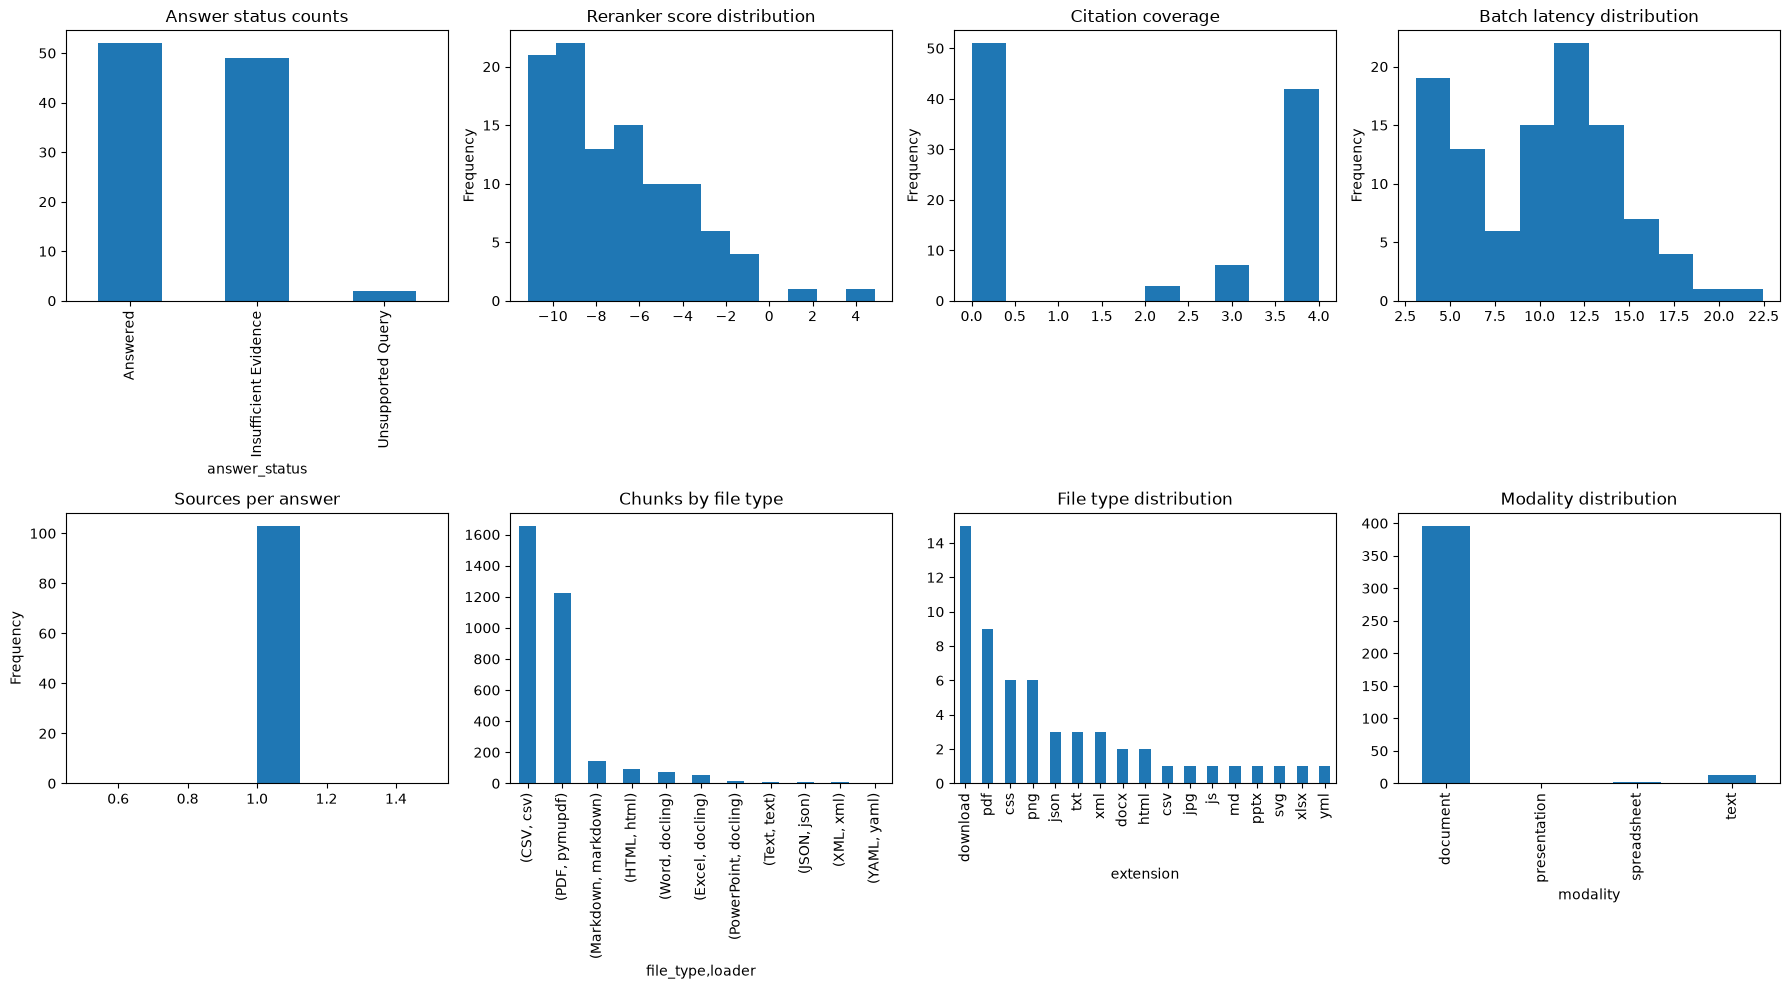

In [13]:
if result is not None:
    rows = pd.read_csv(result.paths.results_csv)
    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.flatten()

    if "answer_status" in rows.columns:
        rows["answer_status"].fillna("unknown").value_counts().plot(kind="bar", ax=axes[0], title="Answer status counts")
    if "average_reranker_score" in rows.columns:
        rows["average_reranker_score"].fillna(0.0).plot(kind="hist", bins=12, ax=axes[1], title="Reranker score distribution")
    if "citation_count" in rows.columns:
        rows["citation_count"].fillna(0).plot(kind="hist", bins=10, ax=axes[2], title="Citation coverage")
    if "total_latency_seconds" in rows.columns:
        rows["total_latency_seconds"].fillna(0.0).plot(kind="hist", bins=10, ax=axes[3], title="Batch latency distribution")

    if "source_files" in rows.columns:
        source_counts = rows["source_files"].fillna("").astype(str).str.split("|").apply(lambda values: len([value for value in values if value]))
        source_counts.plot(kind="hist", bins=8, ax=axes[4], title="Sources per answer")

    if chunks:
        chunk_type_counts = pd.DataFrame(
            [
                {
                    "file_type": chunk.metadata.get("file_format_label", ""),
                    "loader": chunk.metadata.get("loader_type", ""),
                }
                for chunk in chunks
            ]
        )
        chunk_type_counts.value_counts().plot(kind="bar", ax=axes[5], title="Chunks by file type")

    if extension_frame is not None:
        extension_frame.set_index("extension")["count"].plot(kind="bar", ax=axes[6], title="File type distribution")

    if modality_frame is not None:
        modality_frame.set_index("modality")["count"].plot(kind="bar", ax=axes[7], title="Modality distribution")

    plt.tight_layout()
    plt.show()
else:
    display(Markdown("### No batch results available; the visual diagnostics were skipped."))

## 15. Export Generation

The notebook verifies the existing export bundle and the output paths that the Phase 4 runner already generates.

In [14]:
if result is not None:
    exported_paths = [
        result.paths.results_csv,
        result.paths.results_xlsx,
        result.paths.report_html,
        result.paths.summary_json,
        result.paths.metrics_json,
        result.paths.retrieval_json,
    ]
    for path in exported_paths:
        print(f"{path.name}: {'ok' if path.exists() else 'missing'}")
else:
    print("No export bundle generated.")

results.csv: ok
results.xlsx: ok
report.html: ok
summary.json: ok
metrics.json: ok
retrieval.json: ok


## 16. HTML Report Preview

The notebook renders a small preview of the HTML report produced by the existing Phase 4 reporting workflow.

In [15]:
if result is not None and result.paths.report_html.exists():
    html_text = result.paths.report_html.read_text(encoding="utf-8")
    display(Markdown(f"### Report preview for {result.paths.report_html.name}"))
    display(HTML(html_text[:6000]))
else:
    display(Markdown("### No HTML report available yet."))

### Report preview for report.html

## 17. Results Summary

The summary section consolidates the key findings from the deterministic multimodal test run.

In [16]:
if result is not None:
    rows = pd.read_csv(result.paths.results_csv)
    summary_table = pd.DataFrame(
        [
            ("question_count", len(rows)),
            ("answered", int((rows["answer_status"] == "answered").sum())),
            ("insufficient_evidence", int((rows["answer_status"] == "insufficient_evidence").sum())),
            ("unsupported_query", int((rows["answer_status"] == "unsupported_query").sum())),
            ("generation_failed", int((rows["answer_status"] == "generation_failed").sum())),
            ("average_citation_count", round(rows["citation_count"].fillna(0).mean(), 2) if "citation_count" in rows.columns else 0.0),
            ("average_latency_seconds", round(rows["total_latency_seconds"].fillna(0).mean(), 2) if "total_latency_seconds" in rows.columns else 0.0),
        ],
        columns=["metric", "value"],
    )
    display(summary_table)
else:
    display(Markdown("### No batch results were generated; the summary is empty."))

,metric,value
0,question_count,103.00
1,answered,0.00
2,insufficient_evidence,0.00
3,unsupported_query,0.00
4,generation_failed,0.00
5,average_citation_count,1.89
6,average_latency_seconds,10.05


## 18. Known Limitations

- OCR-backed image ingestion requires a working local OCR engine and image quality.
- Some optional loader packages may be unavailable in the current environment; the notebook logs these as dependency_missing warnings instead of crashing.
- Full multimodal quality claims remain out of scope for this deterministic notebook; it focuses on ingestion, indexing, deterministic retrieval, and export compatibility.

## 19. Next Steps

- Place mixed-format test files under [data/files/test](../data/files/test).
- Place one-question-per-line test questions under [data/manual_qa/CIAL_Multimodal_Test_Questions.txt](../data/manual_qa/CIAL_Multimodal_Test_Questions.txt) or point QUESTION_FILE to a specific file.
- Re-run the notebook after adding or changing corpus files to inspect indexing and retrieval behavior.
- Review the generated artifacts in the outputs folder for debugging and regression analysis.